In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import time
import gc
from scipy.stats import zscore
from scipy.signal import detrend
import copy
import sys
from scipy.integrate import simpson as simps
from nice.algorithms.connectivity import epochs_compute_wsmi
import mne
import warnings
warnings.filterwarnings("ignore")
from scipy.ndimage import gaussian_filter1d
import scienceplots as sps
plt.style.use(['science', 'no-latex'])


def smooth_with_gaussian(data, sigma=3):
    return gaussian_filter1d(data, sigma=sigma, axis=1) 

def preprocess(data):   # This will receive (trials, time, neurons). Therefore mean across trials. 
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis = 0)
    std = np.std(data, axis = 0)
   
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    return data_z



c:\Users\joshu\nice\.venv\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


In [17]:
file_numbers = [1, 2, 3, 4, 8, 14, 15, 20, 23]


smi_means = {f'dataset_{file_number}': {'left_attleft': [], 'right_attleft': [], 'left_attright': [], 'right_attright': []} for file_number in file_numbers}
smi_sem = {f'dataset_{file_number}': {'left_attleft': [], 'right_attleft': [], 'left_attright': [], 'right_attright': []} for file_number in file_numbers}

total_time = time.time()
for file_number in  file_numbers:
    file_total = time.time()
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    load_data_start_time = time.time()
    data = pickle.load(open(file_path, 'rb'))
    elapsed_time = time.time() - load_data_start_time
    print(f"Dataset {file_number} loaded in {elapsed_time:.2f} seconds")

    attention_labels = data['label_attend'][0]
    label_left = data['label_left'][0]
    label_right = data['label_right'][0]
    attend_01 = data['attend'][0]
    trial_correct = data['trial_correct'][0]
    omitted = data['omit'][0]
    relevant = np.where((omitted == 0) & (trial_correct == 1))[0]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]

    num_trials, num_samples, num_neurons = left.shape
    num_neurons_attention = 80

    for j in range(0, num_trials):
        for i in range(0, num_neurons):
            count_left = np.count_nonzero(left[j, :, i] == 1)
            if count_left > 0:
                left[j, :, i] /= count_left
            count_right = np.count_nonzero(right[j, :, i] == 1)
            if count_right > 0:
                right[j, :, i] /= count_right

        for i in range(0, num_neurons_attention):
            count_attention = np.count_nonzero(att[j, :, i] == 1)
            if count_attention > 0:
                att[j, :, i] /= count_attention

    left = np.sum(left, axis=2)  # Return a single time series for the output
    right = np.sum(right, axis=2)  # Return a single time series for the output
    att = np.sum(att, axis=2)  # Return a single time series for the output

    left = preprocess(left)
    right = preprocess(right)
    att = preprocess(att) 
   
    # Can now split into left and right attentional modality
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)


    # Splitting left and right
    l_al = smooth_with_gaussian(left[left_indices], sigma = 2)  # Axis 1 will smooth all of these across time
    r_al = smooth_with_gaussian(right[left_indices], sigma = 2)
    a_al = smooth_with_gaussian(att[left_indices], sigma = 2)

    l_ar = smooth_with_gaussian(left[right_indices], sigma = 2)
    r_ar = smooth_with_gaussian(right[right_indices], sigma = 2)
    a_ar = smooth_with_gaussian(att[right_indices], sigma = 2)


    #splitting left and right
    #--------------------- computing smi -------------------
    n_times = l_al.shape[1] ##=250
    print("n_samples", n_times)

    dt = 0.002
    sfreq = 1 / dt

    ch_names = ['left_input', 'right_input', 'attention_layer']
    ch_types = ['eeg', 'eeg', 'eeg']
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)


    #reshaping data for attention left
    raw_data_left = np.concatenate([
        l_al, 
        r_al, 
        a_al 
    ], axis=0)  # Concatenate along time axis

    print("raw_data_left shape =", raw_data_left.shape)  
    # Reshape into (n_channels, n_samples)
    raw_data_left = raw_data_left.reshape(3, -1)  
    print('raw data left reshaped =', raw_data_left.shape) 
    raw_left = mne.io.RawArray(raw_data_left, info)
    print("raw_data_left =", raw_left)
    

    #reshaping date for attention right 
    raw_data_right = np.concatenate([
        l_ar,
        r_ar,
        a_ar 
    ], axis=0)

    raw_data_right = raw_data_right.reshape(3, -1)
    raw_right = mne.io.RawArray(raw_data_right, info)


    #defininf event objects, arrays like [0,0,1], [250, 0, 1], [750, 0, 1] etc
    events_left = np.array([[i * n_times, 0, 1] for i in range(len(l_al))])
    events_right = np.array([[i * n_times, 0, 1] for i in range(len(l_ar))])

    
    print("events_left", events_left[:4])

    epochs_left = mne.Epochs(raw_left, events_left, event_id={'Trial': 1}, tmin=0, tmax =  0.498,  baseline=None, preload=True)
    epochs_right = mne.Epochs(raw_right, events_right, event_id={'Trial': 1}, tmin=0, tmax = 0.498, baseline=None, preload=True)
    print('----------------', (n_times - 1)/ sfreq)

    print("epochs_left", epochs_left)
    #epochs_left.plot(n_epochs=5, n_channels=3, scalings = 'auto', title="Attention Left")
    #plt.show()

    kernel = 3
    taus = [6, 18, 36, 72] 
    smi_results = {'left': {}, 'right': {}}

    for tau in taus:
        tau_samples = int(tau / (1000 / sfreq))
        print(f"tau_samples for {tau}: {tau_samples}")
        
        _, smi_left, _, _ = epochs_compute_wsmi(
            epochs_left, kernel=kernel, tau=tau_samples, backend='python', method_params={'bypass_csd': True}
        )
        smi_results['left'][tau] = smi_left
        #this containts the data for smi at a given tau given attending left. 

        _, smi_right, _, _= epochs_compute_wsmi(
            epochs_right, kernel=kernel, tau=tau_samples, backend='python', method_params={'bypass_csd': True}
        )
        smi_results['right'][tau] = smi_right

        
    for tau in taus:
        smi_means[f'dataset_{file_number}']['left_attleft'].append(np.mean(smi_results['left'][tau][0, 2, :]))
        smi_means[f'dataset_{file_number}']['right_attleft'].append(np.mean(smi_results['left'][tau][1, 2, :]))
        smi_means[f'dataset_{file_number}']['left_attright'].append(np.mean(smi_results['right'][tau][0, 2, :]))
        smi_means[f'dataset_{file_number}']['right_attright'].append(np.mean(smi_results['right'][tau][1, 2, :]))

        smi_sem[f'dataset_{file_number}']['left_attleft'].append((np.std(smi_results['left'][tau][0, 2, :], ddof = 1)) / np.sqrt(len(smi_results['left'][tau][0, 2, :])))
        smi_sem[f'dataset_{file_number}']['left_attright'].append((np.std(smi_results['right'][tau][0, 2, :], ddof = 1)) / np.sqrt(len(smi_results['right'][tau][0, 2, :])))
        smi_sem[f'dataset_{file_number}']['right_attleft'].append((np.std(smi_results['left'][tau][1, 2, :], ddof = 1)) / np.sqrt(len(smi_results['left'][tau][1, 2, :])))
        smi_sem[f'dataset_{file_number}']['right_attright'].append((np.std(smi_results['right'][tau][1, 2, :], ddof = 1)) / np.sqrt(len(smi_results['right'][tau][1, 2, :])))

    del l_al, r_al, a_al, l_ar, r_ar, a_ar, data
    gc.collect()
    print(f'Dataset {file_number} complete in', time.time() - file_total)

print('total time elapsed =', time.time() - total_time)


Dataset 1 loaded in 11.68 seconds
n_samples 250
raw_data_left shape = (984, 250)
raw data left reshaped = (3, 82000)
Creating RawArray with float64 data, n_channels=3, n_times=82000
    Range : 0 ... 81999 =      0.000 ...   163.998 secs
Ready.
raw_data_left = <RawArray | 3 x 82000 (164.0 s), ~1.9 MB, data loaded>
Creating RawArray with float64 data, n_channels=3, n_times=87500
    Range : 0 ... 87499 =      0.000 ...   174.998 secs
Ready.
events_left [[  0   0   1]
 [250   0   1]
 [500   0   1]
 [750   0   1]]
Not setting metadata
Not setting metadata
328 matching events found
No baseline correction applied
0 projection items activated
Loading data for 328 events and 250 original time points ...
0 bad epochs dropped
Not setting metadata
Not setting metadata
350 matching events found
No baseline correction applied
0 projection items activated
Loading data for 350 events and 250 original time points ...
0 bad epochs dropped
---------------- 0.498
epochs_left <Epochs |  328 events (all g

In [24]:
taus = [0,1,2,3]
#want a single plot, where for each dataset, mean pearson in and mean pearson out are plotted with error bars
smi_in = {f'{tau}': [] for tau in taus}
smi_out = {f'{tau}': [] for tau in taus}
errors_in = {f'{tau}': [] for tau in taus}
errors_out = {f'{tau}': [] for tau in taus}


for file_number in file_numbers:
    values = []
    errors = []
    for tau in taus:
        for condition in ['left_attleft', 'right_attright']:
            values.append(smi_means[f'dataset_{file_number}'][condition][tau])
            errors.append(smi_sem[f'dataset_{file_number}'][condition][tau] ** 2)
        smi_in[f'{tau}'].append(np.mean(values))
        errors_in[f'{tau}'].append(np.sqrt((errors[0] + errors[1]) / 4))
    values = []
    errors = []
    for tau in taus:
        for condition in ['left_attright', 'right_attleft']:
            values.append(smi_means[f'dataset_{file_number}'][condition][tau])
            errors.append(smi_sem[f'dataset_{file_number}'][condition][tau] ** 2)
        smi_out[f'{tau}'].append(np.mean(values))
        errors_out[f'{tau}'].append(np.sqrt((errors[0] + errors[1]) / 4))

max_values = {f'{tau}': [] for tau in taus}
min_values = {f'{tau}': [] for tau in taus}

idx = np.arange(len(file_numbers))
for tau in taus:
    values = []
    for f in idx:
        values.append(smi_in[f'{tau}'][f])
        values.append(smi_out[f'{tau}'][f])
    max_values[f'{tau}'].append(max(values))
    min_values[f'{tau}'].append(min(values))


tau_values = [6, 18, 36, 72]
N_ticks = 5


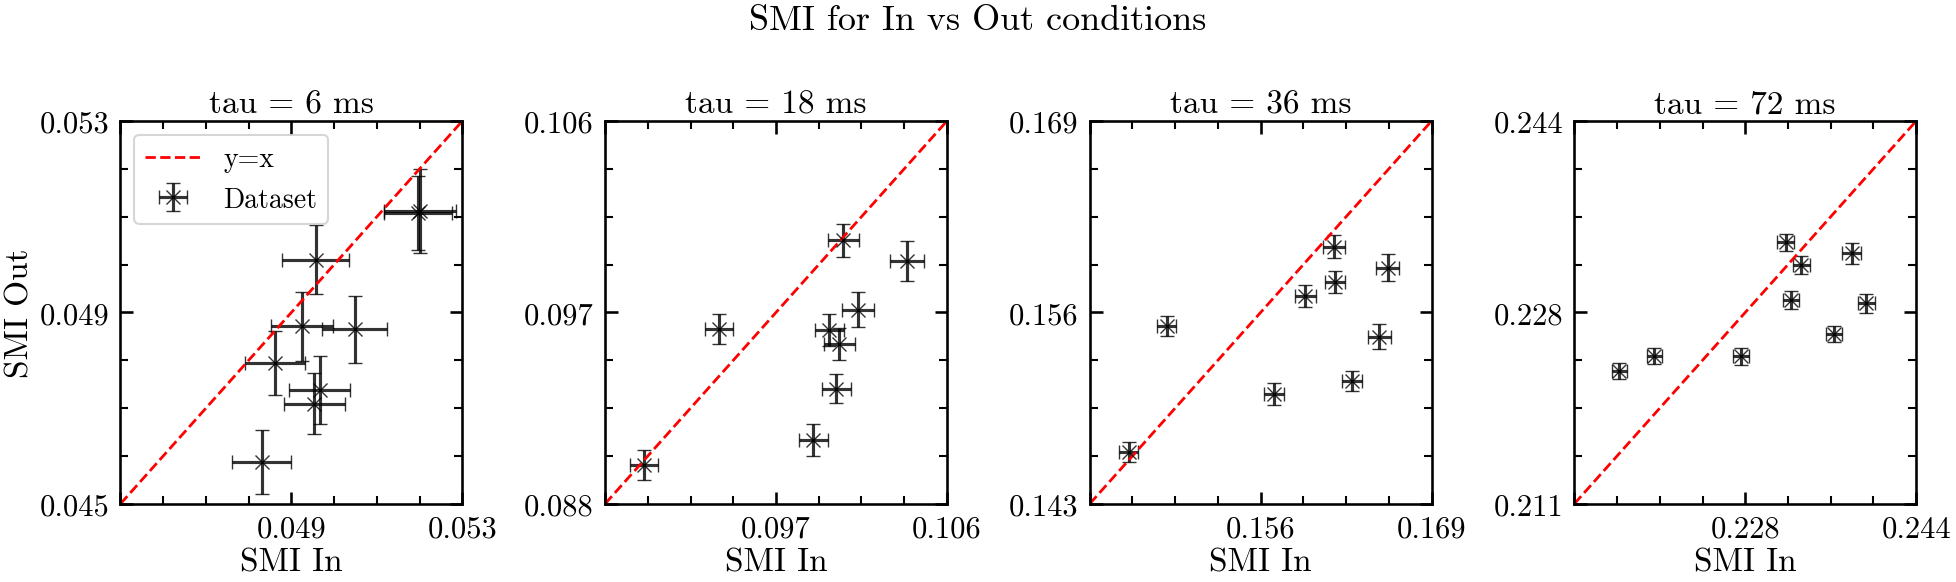

In [25]:
fig, axs = plt.subplots(1, 4, figsize=(20, 6))  # Larger figure size for bigger plot boxes
for tau, i in zip(taus, range(4)):

    #numpy arrays for error bars
    in_vals = np.array(smi_in[f'{tau}'])
    out_vals = np.array(smi_out[f'{tau}'])
    in_errs = np.array(errors_in[f'{tau}'])
    out_errs = np.array(errors_out[f'{tau}'])

    #scatter with error bars
    axs[i].errorbar(in_vals, out_vals,
                     xerr=in_errs, yerr=out_errs,
                       fmt='x', color='k', alpha=0.8, markersize=10, capsize=5, label='Dataset')
    
    #y=x reference line in red dashed style
    local_min = min_values[f'{tau}'][0] * 0.98
    local_max = max_values[f'{tau}'][0] * 1.02
    axs[i].plot([local_min, local_max], [local_min, local_max], 'r--', linewidth=2, label='y=x')
    tick_values = np.linspace(local_min, local_max, 3)

    axs[i].set_xlim(local_min, local_max)
    axs[i].set_ylim(local_min, local_max)
    axs[i].set_xticks(tick_values)
    axs[i].set_yticks(tick_values)
    xticklabels = [f"{tick:.3f}" for tick in tick_values]
    xticklabels[0] = ''  
    axs[i].set_xticklabels(xticklabels, fontsize=22)
    axs[i].set_yticklabels([f"{tick:.3f}" for tick in tick_values], fontsize=22)
    axs[i].set_xlabel('SMI In', fontsize=24)
    axs[i].tick_params(axis='both', which='major', pad=8)

    if i == 0:
        axs[0].set_ylabel('SMI Out', fontsize=24)
        for label in axs[0].get_yticklabels():
            label.set_rotation(0)
        axs[0].legend(fontsize=20, loc='upper left', frameon=True)
    axs[i].set_title(f'tau = {tau_values[tau]} ms', fontsize=24)

fig.suptitle('SMI for In vs Out conditions', fontsize=26, y=1)
plt.tight_layout(rect=[0, 0, 1, 1]) 
plt.show()



In [26]:
from scipy.stats import ttest_rel

taus = ['0', '1', '2', '3']
ttest_results = {}

for tau in taus:
    t_stat, p_val = ttest_rel(smi_in[tau], smi_out[tau])
    ttest_results[tau] = {'t_stat': t_stat, 'p_value': p_val}
    print(f"tau={tau}: t={t_stat:.4f}, p={p_val:.4f}")

#wilcoxon_results = {}
for tau in taus:
    from scipy.stats import wilcoxon
    w_stat, p_val = wilcoxon(smi_in[tau], smi_out[tau])
    #wilcoxon_results[tau] = {'w_stat': w_stat, 'p_value': p_val}
    print(f"tau={tau}: W={w_stat:.4f}, p={p_val:.4f}")


tau=0: t=3.6957, p=0.0061
tau=1: t=3.0272, p=0.0164
tau=2: t=2.1137, p=0.0675
tau=3: t=1.0798, p=0.3117
tau=0: W=1.0000, p=0.0078
tau=1: W=3.0000, p=0.0195
tau=2: W=6.0000, p=0.0547
tau=3: W=14.0000, p=0.3594


In [27]:
from statsmodels.stats.multitest import multipletests

p_vals = [ttest_results[t]['p_value'] for t in taus]
rej, p_corr, _, _ = multipletests(p_vals, method='fdr_bh')

for tau, pcorr, is_sig in zip(taus, p_corr, rej):
    print(f"tau={tau}: corrected p = {pcorr:.4f} → {'SIGNIFICANT' if is_sig else 'n.s.'}")


tau=0: corrected p = 0.0243 → SIGNIFICANT
tau=1: corrected p = 0.0328 → SIGNIFICANT
tau=2: corrected p = 0.0900 → n.s.
tau=3: corrected p = 0.3117 → n.s.


sigma = 1 (smooth last)
tau=0: t=3.4299, p=0.0110
tau=1: t=2.2692, p=0.0575
tau=2: t=1.8042, p=0.1142
tau=3: t=0.8958, p=0.4001
sigma = 2 ( not smoothed lst?)
tau=0: t=2.8170, p=0.0259
tau=1: t=2.2872, p=0.0560
tau=2: t=2.0679, p=0.0775
tau=3: t=1.0357, p=0.3348#
sigma = 3 (smooth last)
tau=0: t=3.0620, p=0.0183
tau=1: t=2.2929, p=0.0556
tau=2: t=1.7664, p=0.1207

using: sigma 2 smooth last
tau=0: t=3.1784, p=0.0155
tau=1: t=2.4440, p=0.0445
tau=2: t=1.8408, p=0.1082
tau=3: t=0.9196, p=0.3884

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scienceplots as sps


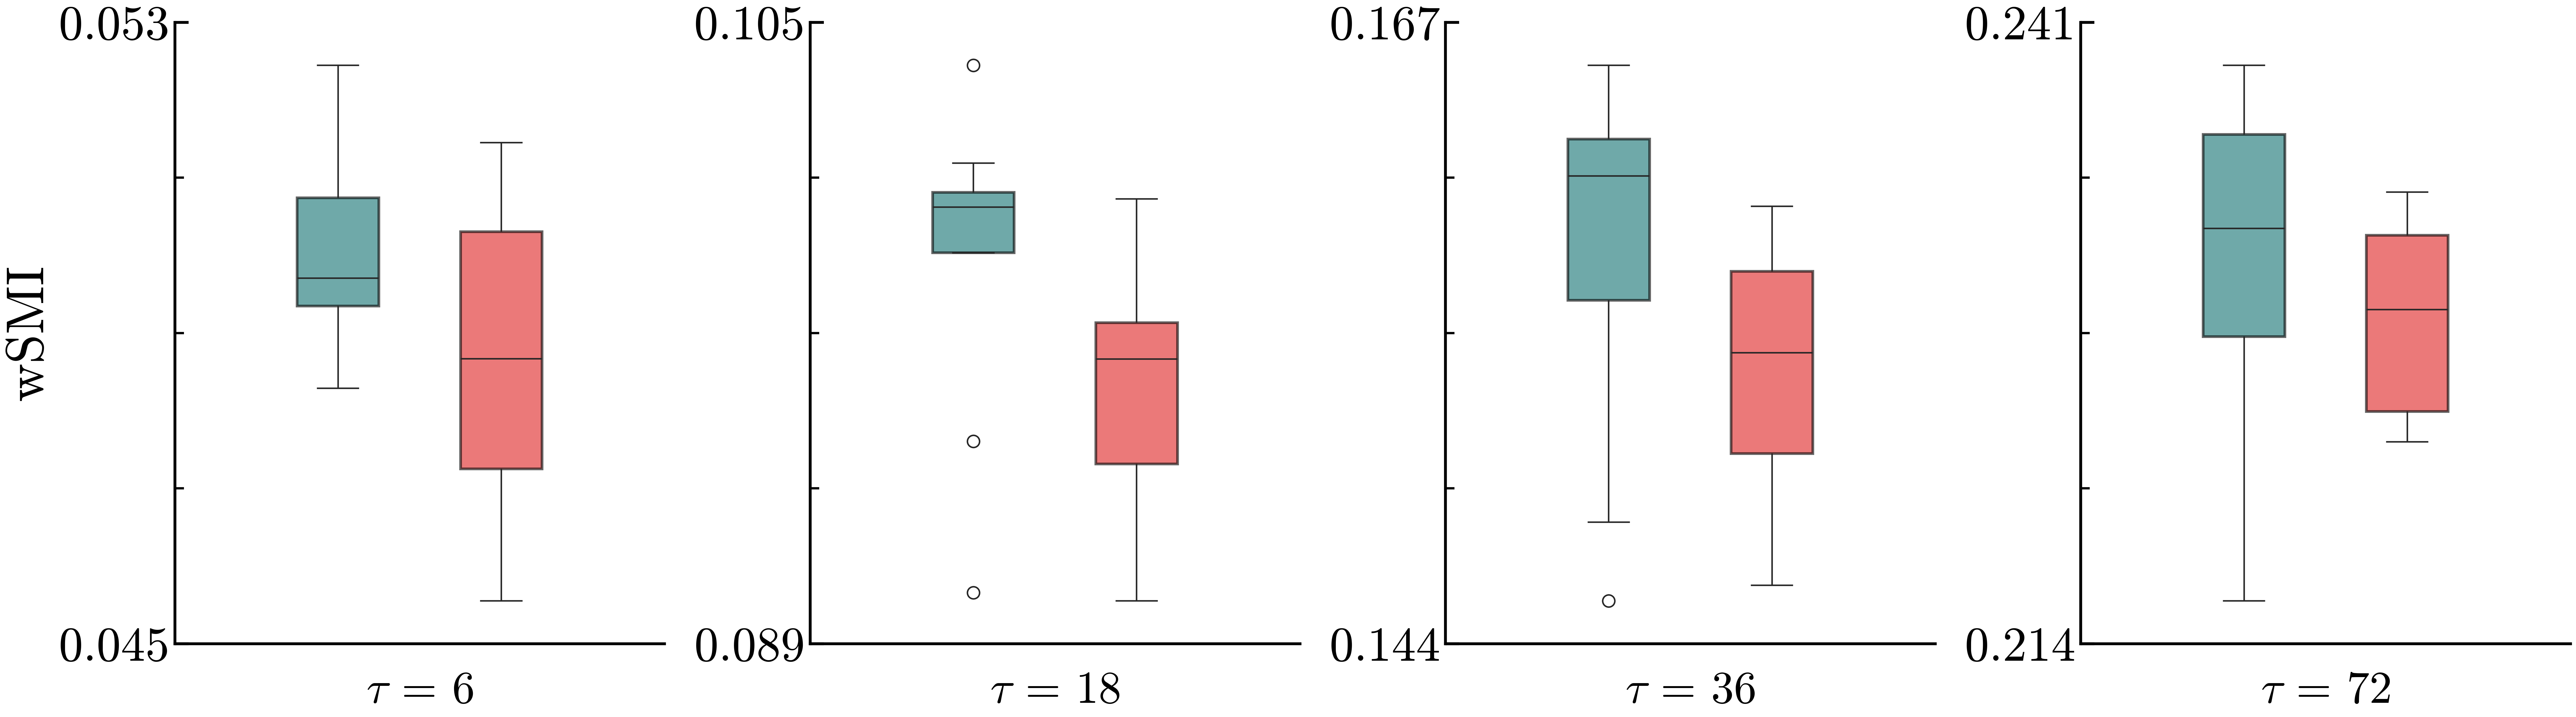

In [29]:
plt.style.use(['science', 'notebook', 'no-latex'])
sns.set_context("talk", font_scale=1.0)
tau_labels = ['6', '18', '36', '72']
# 1) Build DataFrame for all tau values
smi_data = []
for i, tau in enumerate(taus):
    for ds_idx in range(len(smi_in[str(tau)])):
        smi_data.append({"Tau": tau_labels[i], "Value": smi_in[str(tau)][ds_idx], "Condition": "In"})
        smi_data.append({"Tau": tau_labels[i], "Value": smi_out[str(tau)][ds_idx], "Condition": "Out"})
df_smi = pd.DataFrame(smi_data)

# 2) Plot: 4 subplots, one for each tau
fig, axs = plt.subplots(1, 4, figsize=(24, 7), sharey=False, dpi = 400)
for i, tau in enumerate(tau_labels):
    ax = axs[i]
    df_tau = df_smi[df_smi["Tau"] == tau]
  
    sns.boxplot(
        data=df_tau, x="Condition", y="Value",
        width=0.5, fliersize=8, ax=ax,
        palette={"In": "teal", "Out": "red"},
        boxprops=dict(alpha=0.6, linewidth=1.78, edgecolor="k"
        
    ))


    
    # Dynamically set y-limits for each subplot
    y_min = df_tau['Value'].min()
    y_max = df_tau['Value'].max()
    y_range = y_max - y_min
    y_margin = y_range * 0.08 if y_range > 0 else 0.01
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

    # Set only two y-ticks: bottom and top
    ax.set_yticks([y_min - y_margin, y_max + y_margin])
    ax.set_yticklabels([f"{y_min - y_margin:.3f}", f"{y_max + y_margin:.3f}"])

    if i == 0:
        ax.set_ylabel("wSMI", fontsize=35)
    else:
        ax.set_ylabel("")
    
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='y', labelsize=32, right=False)



    #x
    ax.set_xlabel("")
    ax.set_xlim(-1, 2)
    ax.set_xticks([])
    ax.set_xlabel(r'$\tau$ = ' + str(tau), fontsize=30, labelpad=18)
    ax.tick_params(axis='x', labelsize=22)
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False, trim=True)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='teal', edgecolor='k', label='In', alpha=0.5),
    Patch(facecolor='red', edgecolor='k', label='Out', alpha=0.5)
]
# fig.legend(handles=legend_elements, loc='upper right', fontsize=25, frameon=False)

# fig.suptitle('', fontsize=30)
plt.tight_layout()
plt.show()